In [149]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Annotated, Literal
from pydantic import Field,BaseModel
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.messages import SystemMessage,HumanMessage,AIMessage
import operator

In [150]:
load_dotenv()

True

In [151]:
generator_model = ChatGroq(model="openai/gpt-oss-20b")

In [152]:
evaluator_model = ChatGroq(model="openai/gpt-oss-120b")

In [153]:
optimizer_model = ChatGroq(model="openai/gpt-oss-20b")

In [154]:
class EvaluationSchema(BaseModel):
    evaluation: Literal["approved",'need_improvement']=Field(description="evaluate result")
    feedback: str=Field(description="The feedback for the linkedin post")


In [155]:
class LinkedinState(TypedDict):
    topic:str
    post: str
    evaluation: Literal["approved","need_improvement"]
    feedback: str
    iteration_count : int
    max_iteration: int

    post_history = Annotated[list[str],operator.add]
    feedback_history = Annotated[list[str],operator.add]
        

In [156]:
structured_model = evaluator_model.with_structured_output(EvaluationSchema,method="json_schema")

In [157]:
def generator(state:LinkedinState)->LinkedinState:
    messages = [
        SystemMessage(content="You are a funny and clever Linkedin influencer."),
        HumanMessage(content=f"""
            Write a short, original, and hilarious Linkedin post on the topic: "{state['topic']}".

            Rules:
            - Do NOT use question-answer format.
            - Max 400 characters.
            - Use observational humor, irony, sarcasm, or cultural references.
            - Think in meme logic, punchlines, or relatable takes.
            - Use simple, day to day english
            """)
                ]

    # send generator_llm
    response = generator_model.invoke(messages).content

    # return response
    return {'post': response, 'post_history': [response]}

In [158]:
def evaluator(state: LinkedinState)->LinkedinState:
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Linkedin critic. You evaluate Linkedin post based on humor, originality, virality, and Linkedin post format."),
    HumanMessage(content=f"""
        Evaluate the following post:

        Tweet: "{state['post']}"

        Use the criteria below to evaluate the post:

        1. Originality – Is this fresh, or have you seen it a hundred times before?  
        2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
        3. Punchiness – Is it short, sharp, and scroll-stopping?  
        4. Virality Potential – Would people retweet or share it?  
        5. Format – Is it a well-formed post (not a setup-punchline joke, not a Q&A joke, and under 400 characters)?

        Auto-reject if:
        - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
        - It exceeds 400 characters
        - It reads like a traditional setup-punchline joke
        - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

        ### Respond ONLY in structured format:
        - evaluation: "approved" or "need_improvement"  
        - feedback: One paragraph explaining the strengths and weaknesses 
        """)
        ]

    response = structured_model.invoke(messages)

    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [159]:
def optimizer(state:LinkedinState)->LinkedinState:
    messages = [
        SystemMessage(content="You punch up Linkedin post for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the Linkedin post based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['post']}

Re-write it as a short, viral-worthy Linkedin post. Avoid Q&A style and stay under 400 characters.
""")
    ]

    response = optimizer_model.invoke(messages).content
    iteration_count = state['iteration_count'] + 1

    return {'post': response, 'iteration_count': iteration_count, 'post_history': [response]}

In [160]:
def route_eval(state:LinkedinState):
    if state["evaluation"]=="approved" and state["iteration_count"]>=state["max_iteration"]:
        return "approved"
    else:
        return "need_improvement"

In [161]:
graph = StateGraph(LinkedinState)
graph.add_node("generator",generator)
graph.add_node("evaluator",evaluator)
graph.add_node("optimizer",optimizer)


In [162]:
graph.add_edge(START,"generator")
graph.add_edge("generator","evaluator")
graph.add_conditional_edges("evaluator",route_eval,{"approved":END,"need_improvement":"optimizer"})
graph.add_edge("optimizer","evaluator")

In [163]:
workflow = graph.compile()

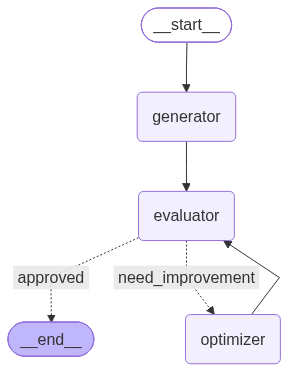

In [164]:
workflow

In [165]:
initial_state ={
    "topic": "why failure after hardwork is not a bad thing",
    "iteration_count": 1,
    "max_iteration":2
}

In [166]:
result=workflow.invoke(initial_state)

In [167]:
result

{'topic': 'why failure after hardwork is not a bad thing',
 'post': 'Hard work is like coding a feature for 48\u202fhrs, then the compiler throws a tantrum. Failure isn’t a bug; it’s the debugger pointing you to the clean code you need. Celebrate the crash, refactor, ship again. #FailForward #GrowthMindset #Iterate',
 'evaluation': 'approved',
 'feedback': 'The post delivers a fresh, tech‑centric metaphor that feels original enough for a developer audience, and its witty framing of failure as a debugger invites a smile without relying on a classic punch‑line. It stays concise, under 400 characters, and the hashtags boost shareability, giving it decent virality potential. Overall it meets the format rules and offers a punchy, share‑ready insight.',
 'iteration_count': 5,
 'max_iteration': 2}